# Evaluasi & Visualisasi

Notebook ini menghasilkan dua hal:
1. **Evaluasi performa** — membandingkan Spark vs Pandas secara kuantitatif
2. **Visualisasi analitik** — grafik yang menjawab 3 pertanyaan utama proyek

Semua output di sini adalah yang masuk ke laporan jurnal, PPT, dan poster.

In [40]:
from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import time, os

spark = SparkSession.builder \
    .appName("GHGRP_Eval") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

SILVER_PATH   = "/content/drive/MyDrive/ABD/data/silver/ghgrp_silver.parquet"
GOLD_PATH      = "/content/drive/MyDrive/ABD/data/gold/ghgrp_gold.parquet"
BRONZE_PATH   = "/content/drive/MyDrive/ABD/data/bronze/ghgrp_bronze.parquet"
FIG_DIR       = "/content/drive/MyDrive/ABD/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Warna konsisten untuk visualisasi
COLORS = {
    'low_emitter':    '#4CAF50',
    'medium_emitter': '#FF9800',
    'high_emitter':   '#F44336'
}

print("Setup selesai")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup selesai


## Bagian 1 — Evaluasi Performa Spark vs Pandas

Ini adalah metrik kuantitatif yang menjadi kontribusi teknis proyek.
Kita ukur tiga hal:
- **Throughput**: berapa baris yang bisa diproses per detik
- **Waktu pipeline end-to-end**: total waktu dari baca Bronze sampai Gold selesai
- **Storage efficiency**: seberapa kecil Parquet dibanding CSV

**Catatan penting untuk laporan:**  
Untuk dataset 66k baris, Pandas bisa lebih cepat dari Spark pada operasi
sederhana karena Spark punya *overhead* startup dan task scheduling.
Ini bukan kelemahan — ini justru temuan yang jujur dan menunjukkan
kalian memahami kapan Spark worth it (data besar, operasi kompleks, pipeline panjang).

In [41]:
# ── Ukur Pandas baseline ──
t0 = time.time()
df_pd = pd.read_parquet(BRONZE_PATH)
_ = df_pd.groupby('Industry Type (sectors)')['Total reported direct emissions'].agg(['sum','mean','count'])
_ = df_pd[df_pd['Total reported direct emissions'] > 0]
_ = df_pd['Total reported direct emissions'].apply(lambda x: np.log(x+1) if pd.notna(x) and x > 0 else None)
t_pandas = time.time() - t0
throughput_pandas = len(df_pd) / t_pandas

# ── Ukur Spark ──
t0 = time.time()
df_s = spark.read.parquet(SILVER_PATH)
_ = df_s.groupBy('sector_clean').agg(
    F.sum('total_emissions'),
    F.mean('total_emissions'),
    F.count('facility_id')
).collect()
_ = df_s.filter(F.col('total_emissions') > 0).count()
t_spark = time.time() - t0
throughput_spark = df_s.count() / t_spark

# ── Ukur storage efficiency ──
csv_path = BRONZE_PATH.replace('.parquet','.csv')
size_csv = os.path.getsize(csv_path) / (1024*1024) if os.path.exists(csv_path) else None
size_parquet = os.path.getsize(BRONZE_PATH) / (1024*1024)

print("=" * 50)
print("   HASIL EVALUASI PERFORMA")
print("=" * 50)
print(f"\nThroughput Pandas : {throughput_pandas:>10,.0f} baris/detik")
print(f"Throughput Spark  : {throughput_spark:>10,.0f} baris/detik")
print(f"\nWaktu Pandas      : {t_pandas:.2f} detik")
print(f"Waktu Spark       : {t_spark:.2f} detik")
print(f"\nUkuran Parquet    : {size_parquet:.2f} MB")
if size_csv:
    compression = (1 - size_parquet/size_csv)*100
    print(f"Ukuran CSV        : {size_csv:.2f} MB")
    print(f"Kompresi Parquet  : {compression:.1f}% lebih kecil")
print("=" * 50)

   HASIL EVALUASI PERFORMA

Throughput Pandas :    135,331 baris/detik
Throughput Spark  :     33,788 baris/detik

Waktu Pandas      : 0.49 detik
Waktu Spark       : 1.97 detik

Ukuran Parquet    : 2.10 MB
Ukuran CSV        : 6.96 MB
Kompresi Parquet  : 69.9% lebih kecil


### Visualisasi evaluasi performa

Grafik ini yang masuk ke slide PPT bagian "Hasil Evaluasi".
Empat panel menunjukkan empat metrik berbeda sekaligus.

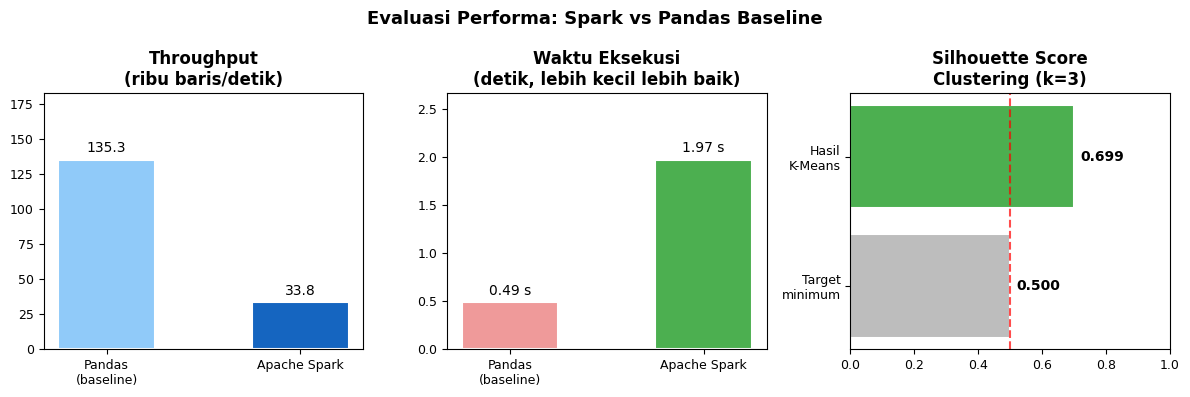

Tersimpan: fig_evaluation.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Evaluasi Performa: Spark vs Pandas Baseline', fontweight='bold', fontsize=13)

# Panel 1: Throughput
ax = axes[0]
vals = [throughput_pandas/1000, throughput_spark/1000]
bars = ax.bar(['Pandas\n(baseline)', 'Apache Spark'], vals,
              color=['#90CAF9', '#1565C0'], width=0.5, edgecolor='white', linewidth=1.5)
ax.set_title('Throughput\n(ribu baris/detik)', fontweight='bold')
ax.bar_label(bars, fmt='%.1f', fontsize=10, padding=3)
ax.set_ylim(0, max(vals)*1.35)
ax.tick_params(labelsize=9)

# Panel 2: Waktu eksekusi
ax = axes[1]
vals2 = [t_pandas, t_spark]
bars2 = ax.bar(['Pandas\n(baseline)', 'Apache Spark'], vals2,
               color=['#EF9A9A', '#4CAF50'], width=0.5, edgecolor='white', linewidth=1.5)
ax.set_title('Waktu Eksekusi\n(detik, lebih kecil lebih baik)', fontweight='bold')
ax.bar_label(bars2, fmt='%.2f s', fontsize=10, padding=3)
ax.set_ylim(0, max(vals2)*1.35)
ax.tick_params(labelsize=9)

# Panel 3: Silhouette score
ax = axes[2]
score = 0.699
target = 0.5
ax.barh(['Target\nminimum', 'Hasil\nK-Means'], [target, score],
        color=['#BDBDBD', '#4CAF50'], edgecolor='white', linewidth=1.5)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Batas ≥ 0.5')
ax.set_title('Silhouette Score\nClustering (k=3)', fontweight='bold')
ax.set_xlim(0, 1)
for i, v in enumerate([target, score]):
    ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: fig_evaluation.png")

## Bagian 2 — Visualisasi Analitik

Baca Gold Layer ke Pandas untuk visualisasi.

**Kenapa pindah ke Pandas untuk visualisasi?**  
Matplotlib dan Seaborn bekerja dengan Pandas DataFrame, bukan Spark DataFrame.
Setelah semua komputasi berat selesai di Spark (Gold Layer),
data yang sudah diagregasi (ratusan baris) aman untuk di-collect ke Pandas.

In [43]:
# Baca Gold Layer
df_gold = spark.read.parquet(GOLD_PATH)
pd_facility = df_gold.toPandas()

# Ambil sector_clean dari Silver Layer
df_silver = spark.read.parquet(SILVER_PATH)
df_sector = df_silver.select('facility_id', 'sector_clean').distinct().toPandas()

# JOIN
pd_facility = pd_facility.merge(df_sector, on='facility_id', how='left')

# Buat emission_category dari kmeans_cluster
cluster_to_category = {
    0: 'medium_emitter',
    1: 'high_emitter',
    2: 'low_emitter'
}
pd_facility['emission_category'] = pd_facility['kmeans_cluster'].map(cluster_to_category)

# Hitung avg_emissions dari Silver
df_avg_total = df_silver.groupBy("facility_id").agg(
    F.mean("total_emissions").alias("avg_emissions")
).toPandas()

# Gabungkan
pd_facility = pd_facility.merge(df_avg_total, on="facility_id", how="left")

# Buat tren dari Silver
df_trend = df_silver.groupBy('sector_clean', 'year') \
    .agg(
        F.sum('total_emissions').alias('total_emissions'),
        F.count('facility_id').alias('facility_count')
    ).orderBy('sector_clean', 'year')
pd_trend = df_trend.toPandas()

print(f"Facility: {pd_facility.shape[0]:,} fasilitas")
print(f"Kolom yang tersedia: {list(pd_facility.columns)}")
print(f"Trend   : {pd_trend.shape[0]} kombinasi sektor-tahun")

Facility: 8,522 fasilitas
Kolom yang tersedia: ['facility_id', 'co2_mean', 'ch4_mean', 'n2o_mean', 'kmeans_cluster', 'dbscan_cluster', 'sector_clean', 'emission_category', 'avg_emissions']
Trend   : 140 kombinasi sektor-tahun


### Gambar 1 — Total emisi per sektor 2014–2023

**Pertanyaan yang dijawab:** Sektor mana yang paling tinggi emisi totalnya?

Ini adalah gambar pertama yang masuk ke poster dan laporan.
Power Plants yang berwarna merah adalah temuan utama —
sektor ini paling dominan dan relevan langsung ke SDG 12.

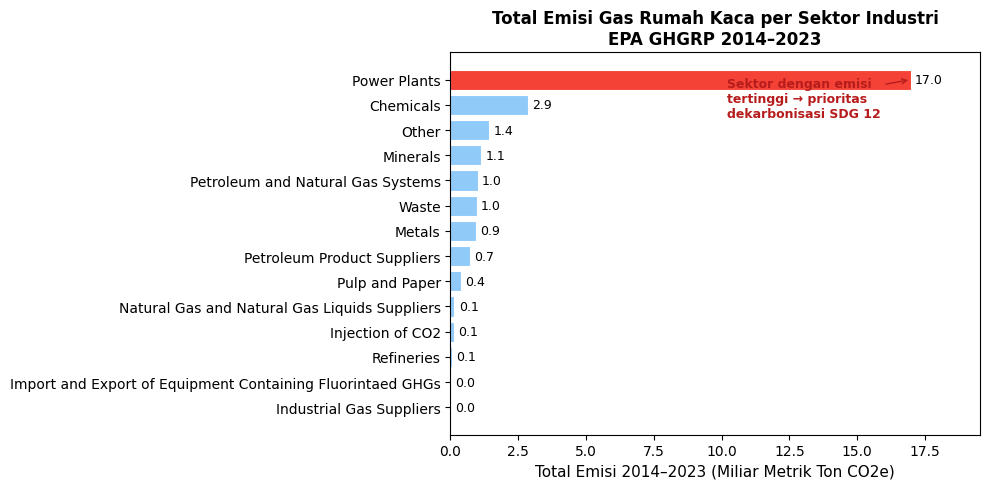

Tersimpan: fig1_sector_total.png


In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

sector_total = pd_trend.groupby('sector_clean')['total_emissions'] \
    .sum().sort_values(ascending=True) / 1e9

# Merah untuk tertinggi
bar_colors = ['#F44336' if v == sector_total.max() else '#90CAF9'
              for v in sector_total.values]

bars = ax.barh(sector_total.index, sector_total.values,
               color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Total Emisi 2014–2023 (Miliar Metrik Ton CO2e)', fontsize=11)
ax.set_title('Total Emisi Gas Rumah Kaca per Sektor Industri\nEPA GHGRP 2014–2023',
             fontweight='bold', fontsize=12)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlim(0, sector_total.max() * 1.15)

# Anotasi
ax.annotate('Sektor dengan emisi\ntertinggi → prioritas\ndekarbonisasi SDG 12',
            xy=(sector_total.max(), len(sector_total)-1),
            xytext=(sector_total.max()*0.6, len(sector_total)-2.5),
            arrowprops=dict(arrowstyle='->', color='#B71C1C'),
            fontsize=9, color='#B71C1C', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_sector_total.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: fig1_sector_total.png")

### Gambar 2 — Tren emisi sektor utama 2014–2023

**Pertanyaan yang dijawab:** Apakah emisi industri membaik atau memburuk?

Ini gambar yang paling kaya cerita untuk laporan dan presentasi.
Area abu-abu menandai 2020 (COVID) — penurunan emisi yang terlihat
di sana bukan karena dekarbonisasi tapi karena penurunan aktivitas industri,
dan ini bisa dijelaskan di laporan sebagai konteks temuan.

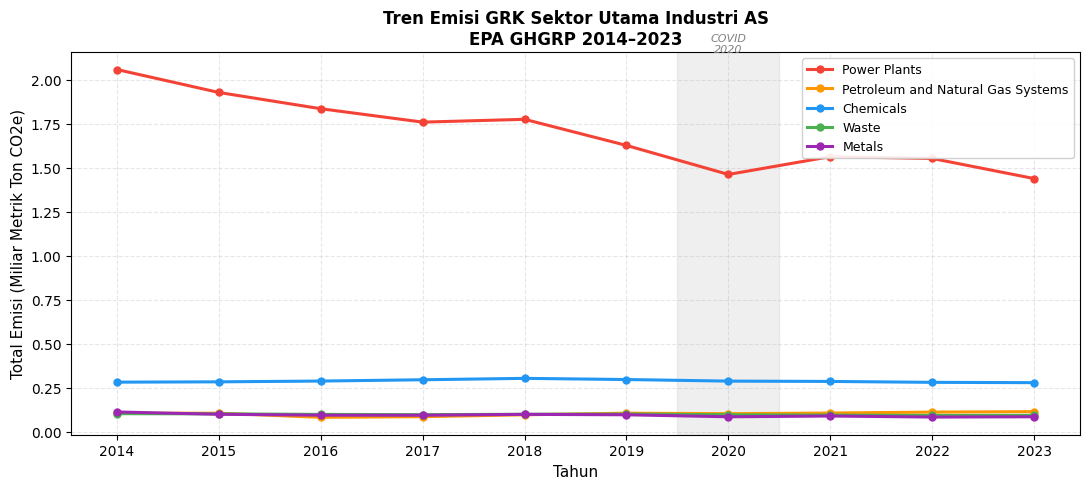

Tersimpan: fig2_trend.png


In [45]:
main_sectors = [
    'Power Plants',
    'Petroleum and Natural Gas Systems',
    'Chemicals',
    'Waste',
    'Metals'
]
line_colors = ['#F44336','#FF9800','#2196F3','#4CAF50','#9C27B0']

fig, ax = plt.subplots(figsize=(11, 5))

for sector, color in zip(main_sectors, line_colors):
    sub = pd_trend[pd_trend['sector_clean'] == sector].sort_values('year')
    ax.plot(sub['year'], sub['total_emissions']/1e9,
            marker='o', label=sector, color=color,
            linewidth=2.2, markersize=5)

# Tandai periode COVID
ax.axvspan(2019.5, 2020.5, alpha=0.12, color='gray')
ax.text(2020, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 1.8,
        'COVID\n2020', ha='center', fontsize=8, color='gray', style='italic')

ax.set_xlabel('Tahun', fontsize=11)
ax.set_ylabel('Total Emisi (Miliar Metrik Ton CO2e)', fontsize=11)
ax.set_title('Tren Emisi GRK Sektor Utama Industri AS\nEPA GHGRP 2014–2023',
             fontweight='bold', fontsize=12)
ax.set_xticks(range(2014, 2024))
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: fig2_trend.png")

### Gambar 3 — Distribusi kategori emisi per sektor (stacked bar)

**Pertanyaan yang dijawab:** Di sektor mana fasilitas high emitter paling banyak?

Ini hasil langsung dari K-Means clustering.
Gambar ini menunjukkan bahwa Power Plants bukan hanya
tinggi total emisinya, tapi juga punya proporsi fasilitas
high emitter terbanyak — temuan yang memperkuat argumen SDG 12.

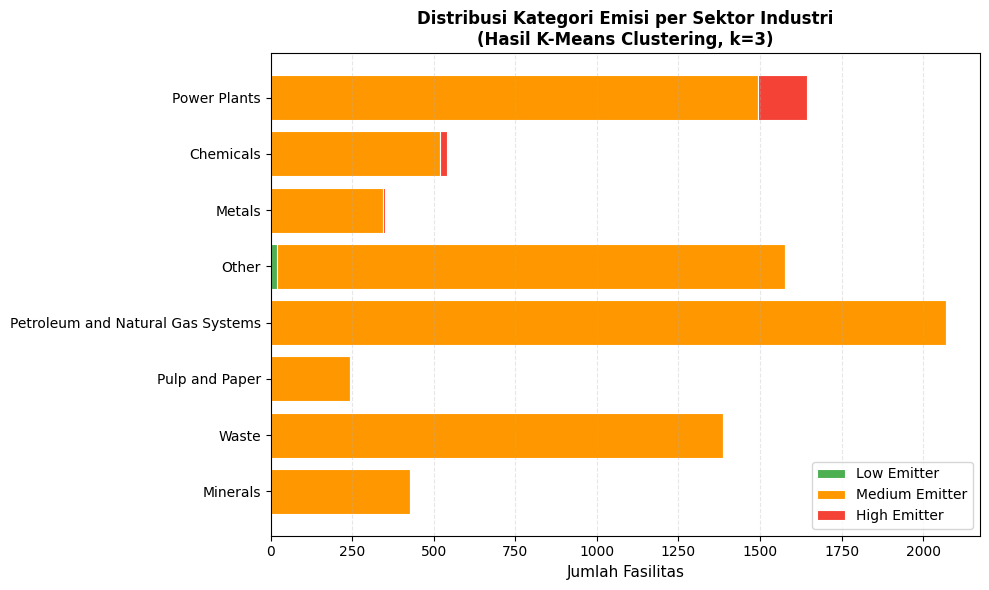

Tersimpan: fig3_cluster_sector.png


In [46]:
# Filter sektor utama
top_sectors = pd_facility['sector_clean'].value_counts().head(8).index
pd_filt = pd_facility[pd_facility['sector_clean'].isin(top_sectors)]

# Gunakan kmeans_cluster langsung
cluster_sector = pd_filt.groupby(['sector_clean', 'kmeans_cluster']).size().unstack(fill_value=0)
cluster_sector = cluster_sector.rename(columns={
    0: 'medium_emitter',
    1: 'high_emitter',
    2: 'low_emitter'
})

# Urutkan berdasarkan jumlah high_emitter
if 'high_emitter' in cluster_sector.columns:
    cluster_sector = cluster_sector.sort_values('high_emitter', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(cluster_sector))

for cat in ['low_emitter', 'medium_emitter', 'high_emitter']:
    if cat in cluster_sector.columns:
        vals = cluster_sector[cat].values
        ax.barh(cluster_sector.index, vals, left=bottom,
                color=COLORS[cat],
                label=cat.replace('_',' ').title(),
                edgecolor='white', linewidth=0.8)
        bottom += vals

ax.set_xlabel('Jumlah Fasilitas', fontsize=11)
ax.set_title('Distribusi Kategori Emisi per Sektor Industri\n(Hasil K-Means Clustering, k=3)',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_cluster_sector.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: fig3_cluster_sector.png")

### Gambar 4 — Pie chart distribusi kategori keseluruhan

Gambar ringkasan yang cocok untuk bagian **abstract** di poster pameran.
Menunjukkan secara cepat berapa persen fasilitas industri AS
masuk kategori high emitter.

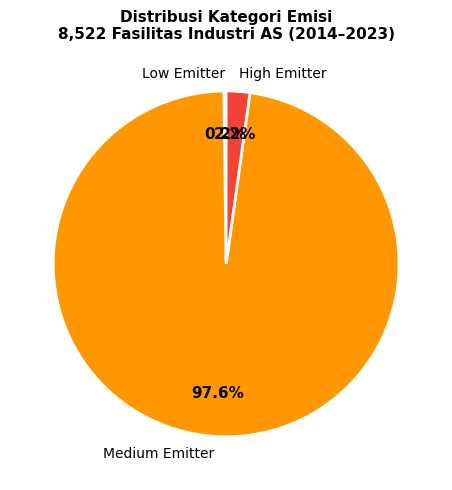

Tersimpan: fig4_pie.png


In [47]:
fig, ax = plt.subplots(figsize=(6, 5))

cat_counts = pd_facility['emission_category'].value_counts()
order = ['low_emitter', 'medium_emitter', 'high_emitter']
cat_counts = cat_counts.reindex([c for c in order if c in cat_counts.index])

labels = [c.replace('_',' ').title() for c in cat_counts.index]
colors_pie = [COLORS[c] for c in cat_counts.index]

wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=labels,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title(f'Distribusi Kategori Emisi\n{len(pd_facility):,} Fasilitas Industri AS (2014–2023)',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_pie.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: fig4_pie.png")

## Bagian 3 — Tabel ringkasan untuk laporan

Tabel ini langsung bisa di-copy ke laporan jurnal
bagian hasil dan pembahasan.

In [48]:
# Tabel 1: Ranking sektor berdasarkan rata-rata emisi per fasilitas
sector_summary = pd_facility.groupby('sector_clean').agg(
    jumlah_fasilitas=('facility_id','count'),
    rata_rata_emisi=('avg_emissions','mean'),
    median_emisi=('avg_emissions','median'),
    pct_high_emitter=('emission_category', lambda x: (x=='high_emitter').mean()*100)
).sort_values('rata_rata_emisi', ascending=False).round(0)

sector_summary['rata_rata_emisi'] = sector_summary['rata_rata_emisi'].apply(lambda x: f"{x:,.0f}")
sector_summary['median_emisi']    = sector_summary['median_emisi'].apply(lambda x: f"{x:,.0f}")
sector_summary['pct_high_emitter']= sector_summary['pct_high_emitter'].apply(lambda x: f"{x:.1f}%")

print("=== RANKING SEKTOR BERDASARKAN INTENSITAS EMISI ===")
print(sector_summary.to_string())

# Tabel 2: Ringkasan metrik evaluasi
print("\n=== TABEL METRIK EVALUASI (untuk laporan) ===")
print(f"{'Metrik':<35} {'Baseline (Pandas)':<22} {'Spark':<15} {'Keterangan'}")
print("-" * 90)
print(f"{'Throughput (baris/detik)':<35} {throughput_pandas:<22,.0f} {throughput_spark:<15,.0f} {'Lebih tinggi = lebih baik'}")
print(f"{'Waktu eksekusi (detik)':<35} {t_pandas:<22.2f} {t_spark:<15.2f} {'Lebih kecil = lebih baik'}")
print(f"{'Silhouette score clustering':<35} {'N/A':<22} {0.699:<15.3f} {'Target ≥ 0.5 ✓'}")
print(f"{'Kompresi Parquet vs CSV':<35} {'baseline (CSV)':<22} {compression:.1f}%{' ':<9} {'Lebih tinggi = lebih efisien' if compression else 'N/A'}")

spark.stop()
print("\n✅ Semua visualisasi tersimpan di folder figures/")
print("  fig_evaluation.png     → slide evaluasi performa")
print("  fig1_sector_total.png  → bar chart total emisi per sektor")
print("  fig2_trend.png         → line chart tren 2014-2023")
print("  fig3_cluster_sector.png → stacked bar clustering")
print("  fig4_pie.png           → pie chart distribusi kategori")

=== RANKING SEKTOR BERDASARKAN INTENSITAS EMISI ===
                                                            jumlah_fasilitas rata_rata_emisi median_emisi pct_high_emitter
sector_clean                                                                                                              
Power Plants                                                            1643       1,110,973      234,936             9.0%
Petroleum Product Suppliers                                               87         992,548      525,062             6.0%
Chemicals                                                                539         562,445      108,415             4.0%
Refineries                                                                17         447,743      143,240             0.0%
Injection of CO2                                                          39         440,246       87,335             5.0%
Metals                                                                   350         27